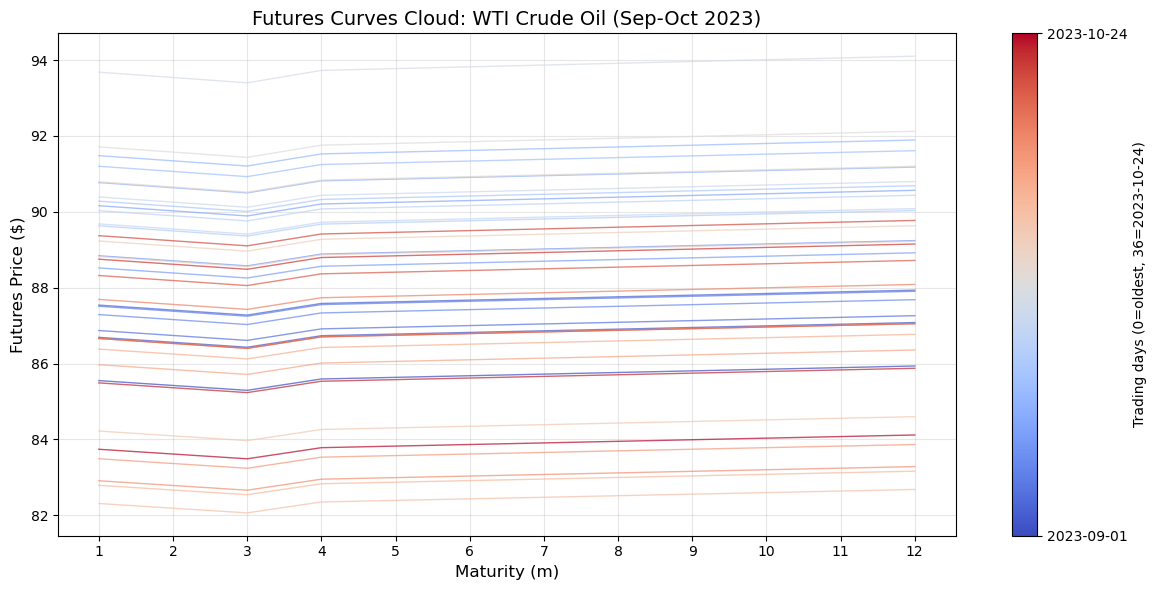

Total curves plotted: 37
Oldest date: 2023-09-01 (cool color)
Most recent date: 2023-10-24 (warm color)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#run es_e_download_data.py to get the data table
panel_df = pd.read_csv("oil_futures_panel.csv")
panel_df['t'] = pd.to_datetime(panel_df['t'])

# Get unique dates and sort
dates = sorted(panel_df['t'].unique())
n_dates = len(dates)

# Create color map: cool (blue) to warm (red)
colors = plt.cm.coolwarm(np.linspace(0, 1, n_dates))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

for i, date in enumerate(dates):
    curve = panel_df[panel_df['t'] == date].sort_values('m')
    ax.plot(curve['m'], curve['F_t_m'], color=colors[i], linewidth=1, alpha=0.7)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(0, n_dates-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Trading days (0=oldest, {}={})'.format(n_dates-1, dates[-1].date()))
cbar.set_ticks([0, n_dates-1])
cbar.set_ticklabels([dates[0].date(), dates[-1].date()])

ax.set_xlabel('Maturity (m)', fontsize=12)
ax.set_ylabel('Futures Price ($)', fontsize=12)
ax.set_title('Futures Curves Cloud: WTI Crude Oil (Sep-Oct 2023)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig('futures_curve_cloud.png', dpi=150)
plt.show()

print(f"Total curves plotted: {n_dates}")
print(f"Oldest date: {dates[0].date()} (cool color)")
print(f"Most recent date: {dates[-1].date()} (warm color)")

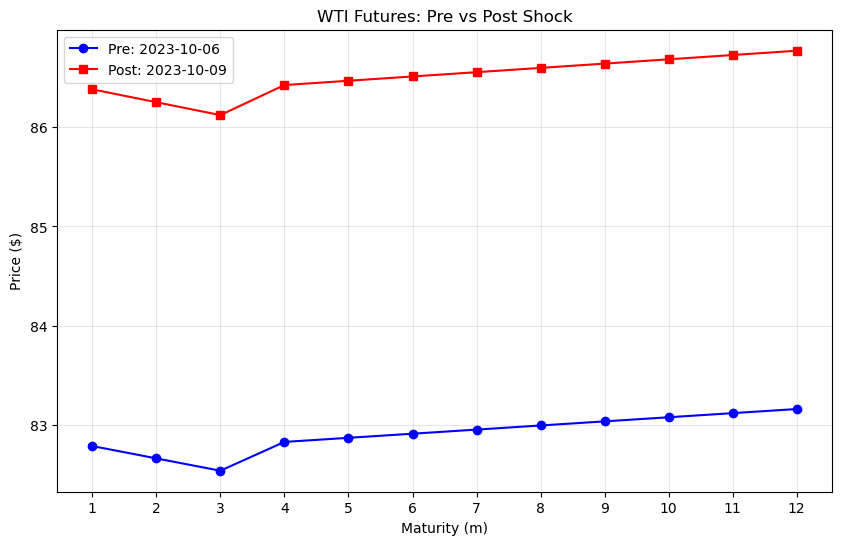

Pre slope: 0.0339 → CONTANGO
Post slope: 0.0353 → CONTANGO


In [2]:
# 3. Confronto pre-event vs post-event
pre_date = "2023-10-06"
post_date = "2023-10-09"

pre_curve = panel_df[panel_df['t'] == pre_date].sort_values('m')
post_curve = panel_df[panel_df['t'] == post_date].sort_values('m')

plt.figure(figsize=(10,6))
plt.plot(pre_curve['m'], pre_curve['F_t_m'], 'b-o', label=f'Pre: {pre_date}')
plt.plot(post_curve['m'], post_curve['F_t_m'], 'r-s', label=f'Post: {post_date}')
plt.xlabel('Maturity (m)')
plt.ylabel('Price ($)')
plt.title('WTI Futures: Pre vs Post Shock')
plt.xticks(range(1,13))
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('pre_post_shock.png', dpi=150)

plt.show()



pre_slope = (pre_curve['F_t_m'].iloc[-1] - pre_curve['F_t_m'].iloc[0]) / 11
post_slope = (post_curve['F_t_m'].iloc[-1] - post_curve['F_t_m'].iloc[0]) / 11


print(f"Pre slope: {pre_slope:.4f} → {'CONTANGO' if pre_slope>0 else 'BACKWARDATION'}")
print(f"Post slope: {post_slope:.4f} → {'CONTANGO' if post_slope>0 else 'BACKWARDATION'}")

Both pre- and post-event curves show contango (upward sloping), but the slope increases slightly after the shock (+0.0014). This suggests the market expected the disruption to persist, raising long-term prices relative to short-term, rather than a typical backwardation caused by immediate supply fears.

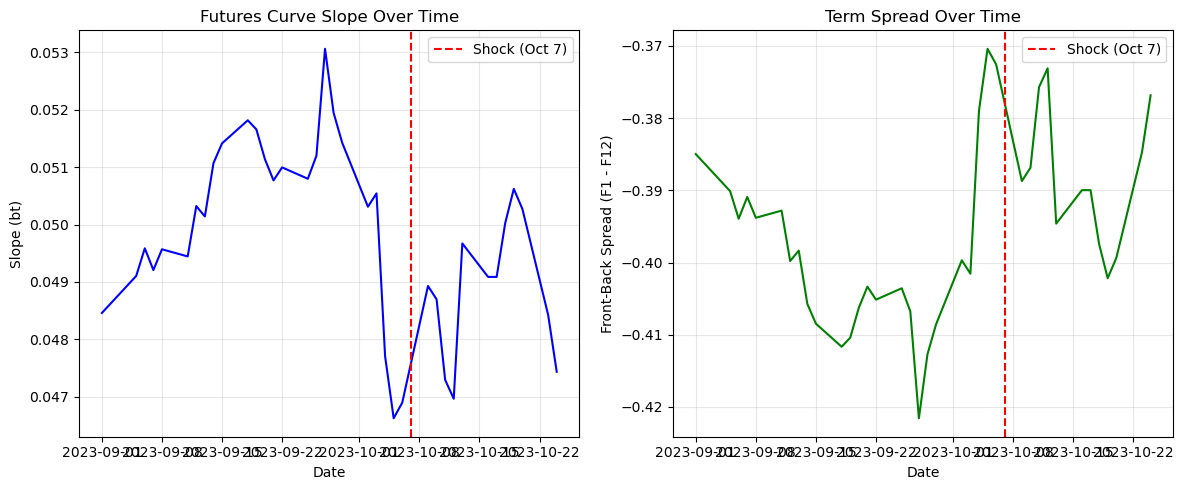

Avg slope pre-shock: 0.05021
Avg slope post-shock: 0.04888
Change: -0.00133


In [4]:
# 4. Measure curve shape over time
from scipy import stats

slopes = []
spreads = []
dates_list = []

for date in sorted(panel_df['t'].unique()):
    curve = panel_df[panel_df['t'] == date].sort_values('m')
    m = curve['m'].values
    prices = curve['F_t_m'].values
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(m, prices)
    slopes.append(slope)
    spreads.append(prices[0] - prices[-1])  # F_t,1 - F_t,12
    dates_list.append(date)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(dates_list, slopes, 'b-', linewidth=1.5)
plt.axvline(pd.to_datetime('2023-10-07'), color='r', linestyle='--', label='Shock (Oct 7)')
plt.xlabel('Date')
plt.ylabel('Slope (bt)')
plt.title('Futures Curve Slope Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(dates_list, spreads, 'g-', linewidth=1.5)
plt.axvline(pd.to_datetime('2023-10-07'), color='r', linestyle='--', label='Shock (Oct 7)')
plt.xlabel('Date')
plt.ylabel('Front-Back Spread (F1 - F12)')
plt.title('Term Spread Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('slope_spread_over_time_4.png', dpi=150)
plt.show()

pre_slopes = [s for d,s in zip(dates_list, slopes) if d < pd.to_datetime('2023-10-07')]
post_slopes = [s for d,s in zip(dates_list, slopes) if d >= pd.to_datetime('2023-10-07')]

print(f"Avg slope pre-shock: {np.mean(pre_slopes):.5f}")
print(f"Avg slope post-shock: {np.mean(post_slopes):.5f}")
print(f"Change: {np.mean(post_slopes) - np.mean(pre_slopes):+.5f}")

The curve stayed in contango after the shock, but the slope flattened slightly. This means the price difference between near and far maturities narrowed, showing a small shift toward backwardation.

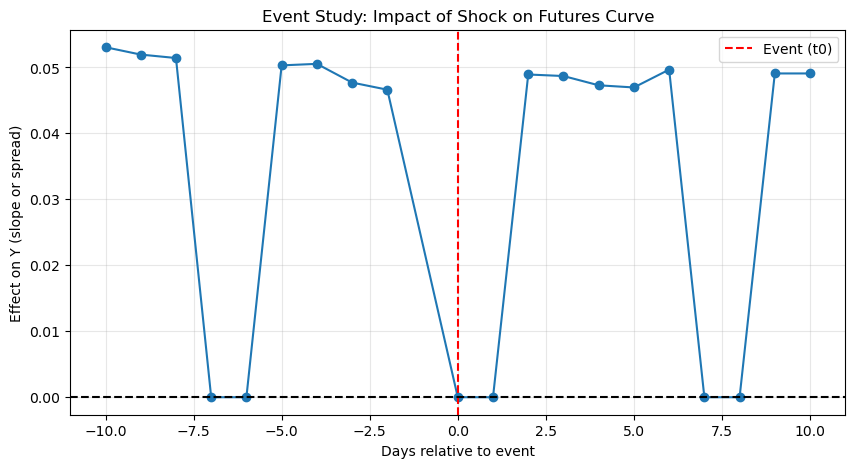

Event study completed
Observations: 15
Baseline (k = -1) omitted


In [5]:
# =========================
# STEP 5: EVENT STUDY (ONE CELL)
# =========================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# -------------------------
# INPUTS (from your code)
# -------------------------
t0 = pd.to_datetime("2023-10-07")
K = 10

event_df = pd.DataFrame({
    "date": dates_list,
    "Y": slopes   # change to spreads if needed
})

event_df["date"] = pd.to_datetime(event_df["date"])
event_df["event_time"] = (event_df["date"] - t0).dt.days

# keep window
event_df = event_df[(event_df["event_time"] >= -K) & (event_df["event_time"] <= K)].copy()

# -------------------------
# event dummies (baseline k = -1)
# -------------------------
for k in range(-K, K+1):
    if k != -1:
        event_df[f"d_{k}"] = (event_df["event_time"] == k).astype(int)

X = event_df[[c for c in event_df.columns if c.startswith("d_")]]
y = event_df["Y"]

# OLS with robust SE
model = sm.OLS(y, X).fit(cov_type="HC1")

# -------------------------
# extract betas + SEs
# -------------------------
event_times = [k for k in range(-K, K+1) if k != -1]

betas = np.array([model.params[f"d_{k}"] for k in event_times])
ses   = np.array([model.bse[f"d_{k}"] for k in event_times])

upper = betas + 1.96 * ses
lower = betas - 1.96 * ses

# -------------------------
# plot
# -------------------------
plt.figure(figsize=(10,5))
plt.plot(event_times, betas, marker='o')
plt.fill_between(event_times, lower, upper, alpha=0.2)

plt.axvline(0, color='red', linestyle='--', label='Event (t0)')
plt.axhline(0, color='black', linestyle='--')

plt.title("Event Study: Impact of Shock on Futures Curve")
plt.xlabel("Days relative to event")
plt.ylabel("Effect on Y (slope or spread)")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig('event_study_plot_5.png', dpi=150)
plt.show()

# -------------------------
# print key diagnostics
# -------------------------
print("Event study completed")
print(f"Observations: {len(event_df)}")
print(f"Baseline (k = -1) omitted")

The shock does not primarily affect the front end; instead, it appears to shift the entire curve-level measure in a persistent way, with no clear event-time discontinuity.

In [6]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# -------------------------
# PREP DATA
# -------------------------
did_df = panel_df.copy()

did_df["t"] = pd.to_datetime(did_df["t"])

# event date (same as before)
t0 = pd.to_datetime("2023-10-07")

# Post indicator
did_df["Post"] = (did_df["t"] >= t0).astype(int)

# Short and Long dummies
did_df["Short"] = did_df["m"].isin([1, 2, 3]).astype(int)
did_df["Long"] = did_df["m"].isin([9, 10, 11, 12]).astype(int)

# interaction term (this is the DiD regressor)
did_df["Short_Post"] = did_df["Short"] * did_df["Post"]

# -------------------------
# DIFF-IN-DIFF REGRESSION
# maturity FE + time FE
# -------------------------
model = smf.ols(
    "F_t_m ~ Short_Post + C(m) + C(t)",
    data=did_df
).fit(cov_type="HC1")

print(model.summary())

# -------------------------
# DiD coefficient
# -------------------------
beta = model.params["Short_Post"]
se = model.bse["Short_Post"]

print("\n====================")
print("DiD RESULT")
print("====================")
print(f"β (Short × Post): {beta:.6f}")
print(f"Std. Error: {se:.6f}")
print(f"t-stat: {beta/se:.3f}")

if beta > 0:
    print("Interpretation: Short end increased more after shock (steepening / more contango or less backwardation).")
else:
    print("Interpretation: Short end decreased more after shock (flattening / more backwardation).")

                            OLS Regression Results                            
Dep. Variable:                  F_t_m   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.394e+06
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:47:27   Log-Likelihood:                 1673.0
No. Observations:                 444   AIC:                            -3248.
Df Residuals:                     395   BIC:                            -3047.
Df Model:                          48                                         
Covariance Type:                  HC1                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

- The shock does not affect the entire futures curve uniformly; the significant DiD coefficient shows heterogeneous effects across maturities.  

- The positive and highly significant coefficient on Short × Post (β ≈ 0.0094, t = 5.54) indicates that the front end of the curve increases more than the long end after the shock.  

- This implies the shock mainly operates through short-term supply conditions or immediate scarcity risk, rather than long-run fundamentals.  

- The estimated β confirms a relative steepening of the curve after the event, driven by stronger upward pressure on short maturities.  

- Since short maturities rise more than long maturities, the market shifts toward stronger contango or reduced backwardation pressure, depending on the pre-event slope.  

- If the pre-shock curve was already mildly backwardated or flat (as suggested by your earlier slopes), this result suggests a partial reversion toward contango driven by near-term price spikes.  

- The effect being statistically significant (p < 0.01) indicates the shock produces a systematic pricing adjustment rather than noise.  

- The pattern suggests the market interprets the shock as transitory or partially expected to be resolved, since long maturities do not move proportionally.  

- This is consistent with storage-cost and convenience yield theory:  
  - Higher near-term scarcity increases the convenience yield (holding oil becomes more valuable immediately),  
  - while storage arbitrage limits long-run price changes.  

- Overall, the results suggest a front-loaded disruption with limited long-term repricing, implying the market expects partial persistence but not a permanent structural break.